In [22]:
import pandas as pd
import seaborn as sbn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split

In [23]:
# dataset = load_iris()
dataset = load_wine()
# dataset = load_diabetes()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
x = dataset.data
y = dataset.target


In [24]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
for col in df.columns:
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [52]:
pca = PCA(n_components=4)
x_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(
    x_pca,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=df.index
)

print(pca.explained_variance_ratio_)

[0.38203095 0.18364233 0.10635    0.06790018]


In [47]:
pca = PCA(n_components=2)
x_pca_2 = pca.fit_transform(df)
df_pca_2 = pd.DataFrame(
    x_pca_2,
    columns=["PC1", "PC2"],
    index=df.index
)

print(pca.explained_variance_ratio_)

[0.38203095 0.18364233]


In [48]:
df_pca.head()

,PC1,PC2,PC3
0,3.441657,1.449756,-0.165164
1,2.404678,-0.331191,-2.026609
2,2.679474,1.034930,0.983074
3,3.856861,2.764106,-0.175447
4,1.251577,0.868489,2.026165


In [49]:
df["class"] = dataset.target
df_pca["class"] = dataset.target
#df_pca_2["class"] = dataset.target
df_pca_2["class"] = pd.Series(dataset.target, index=df.index)[:len(df_pca_2)]

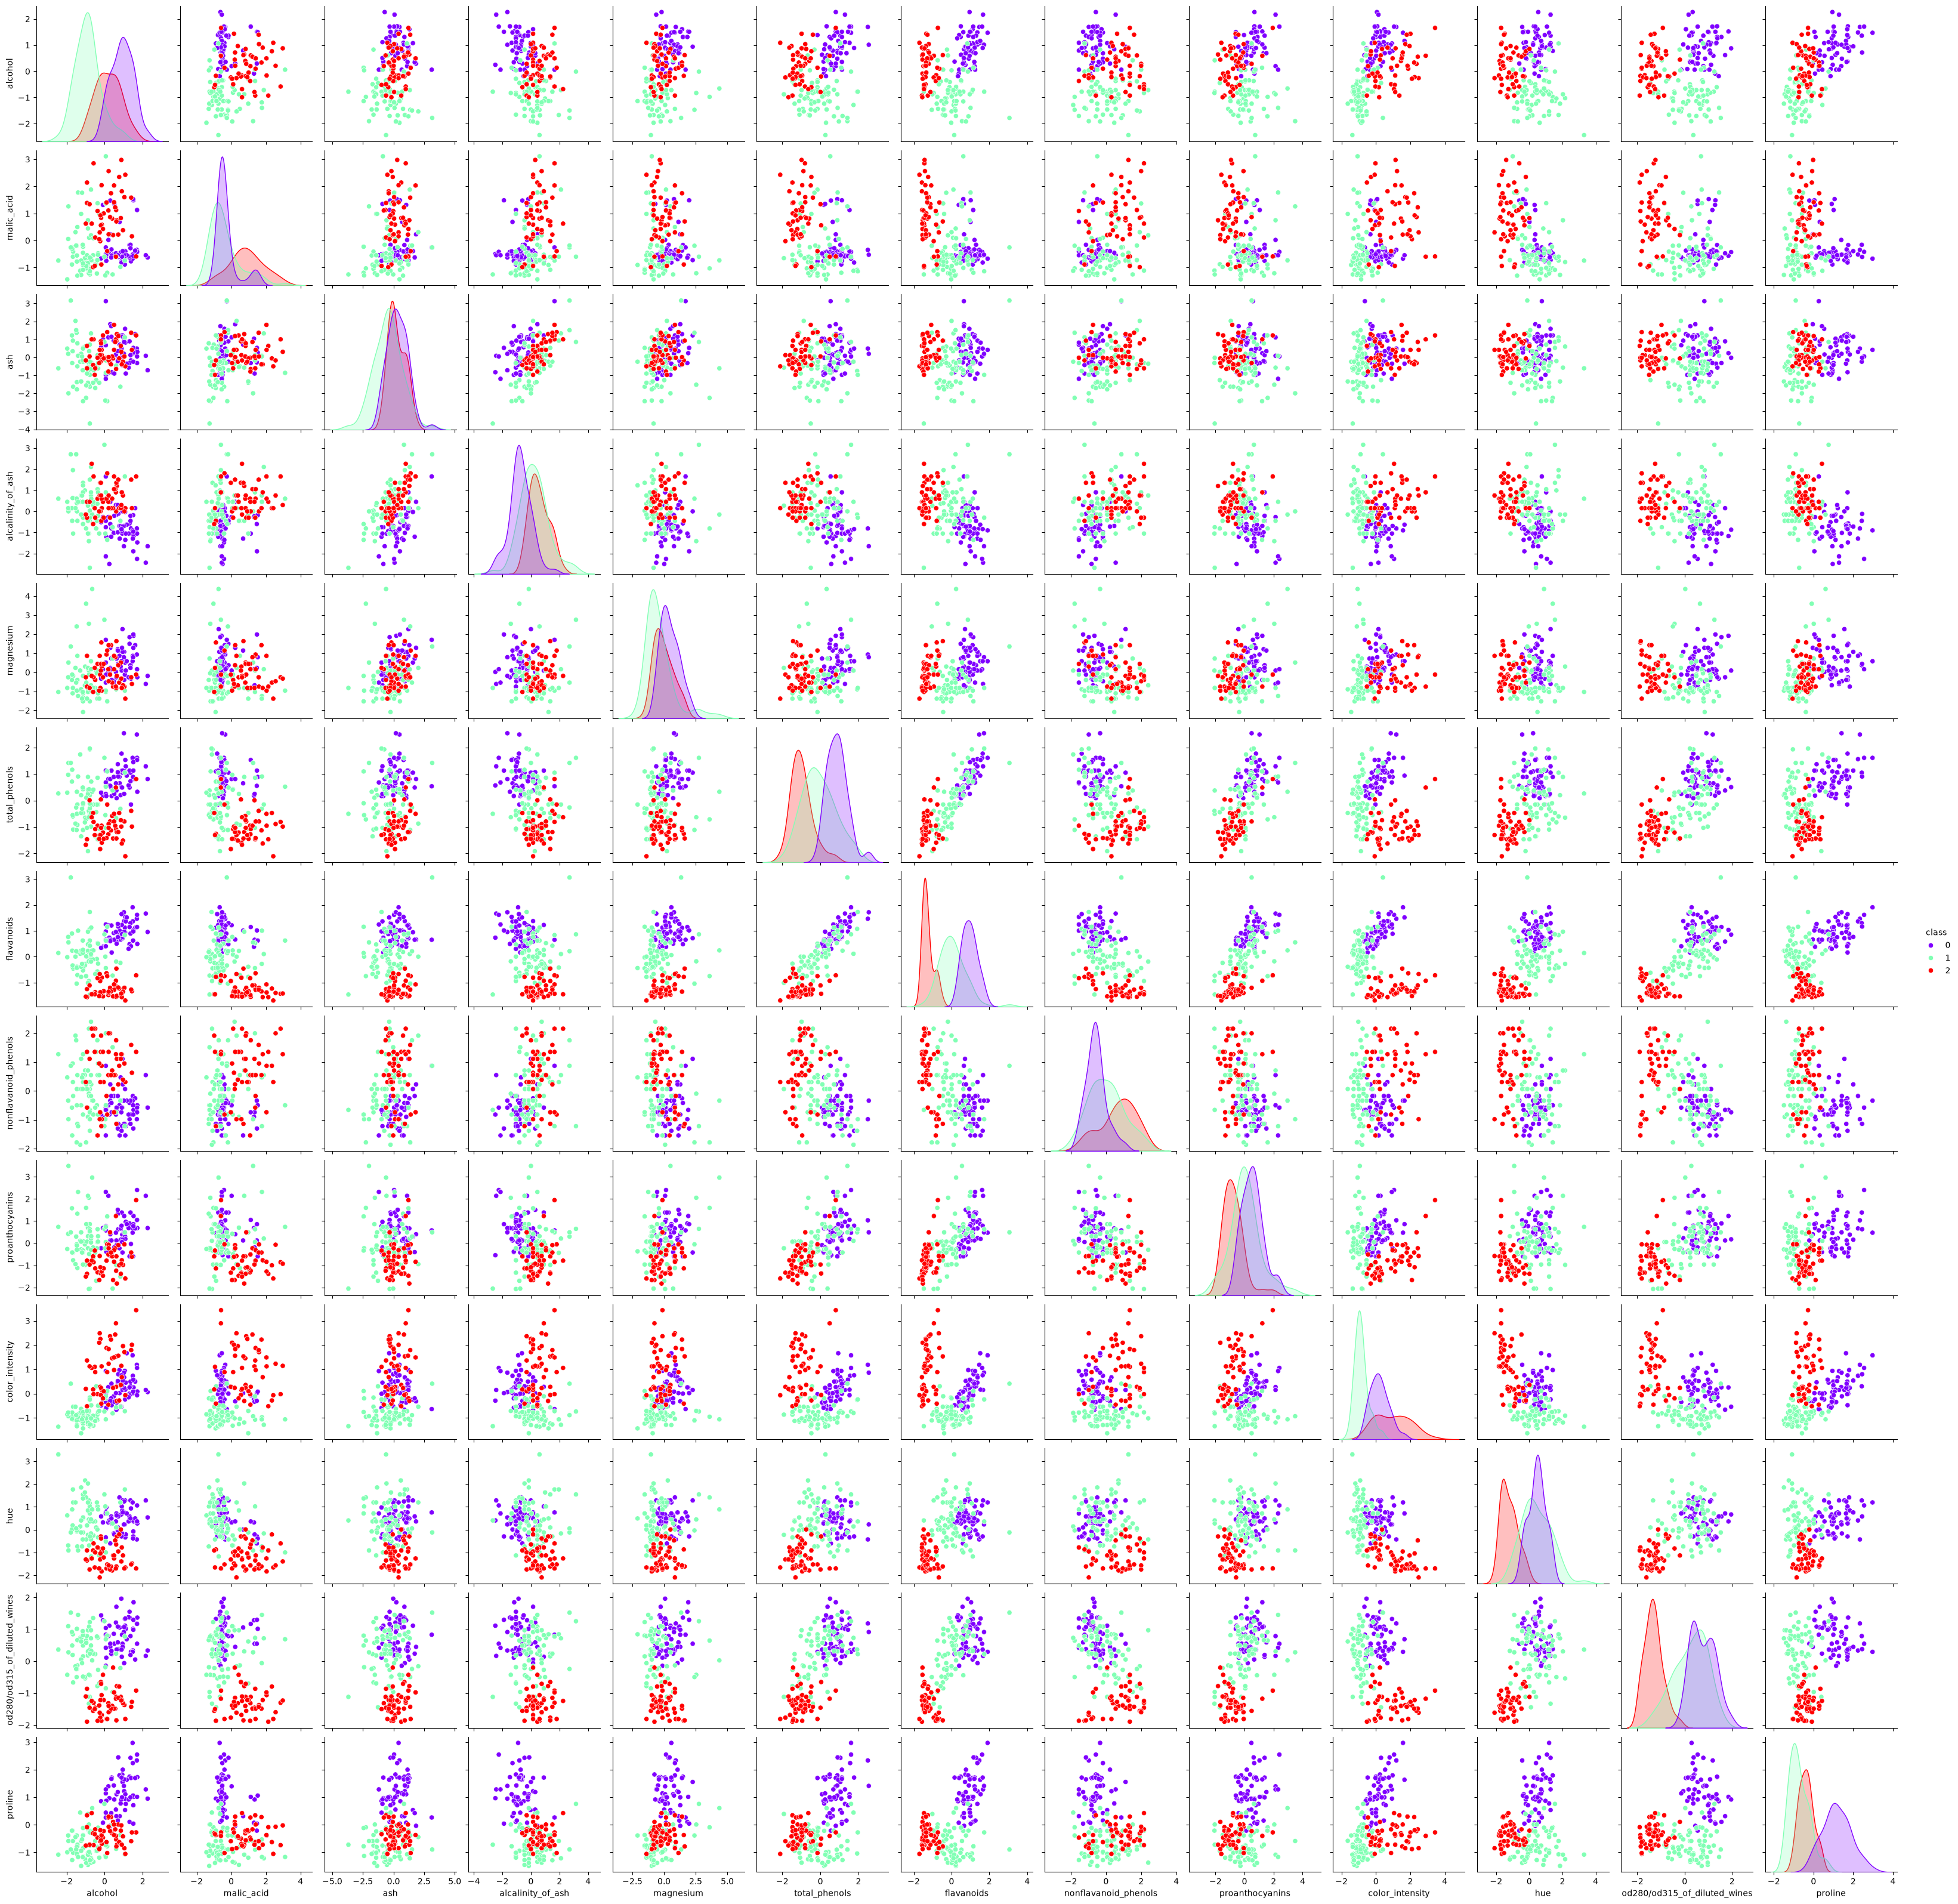

In [42]:
sbn.pairplot(df, hue="class", palette="rainbow")

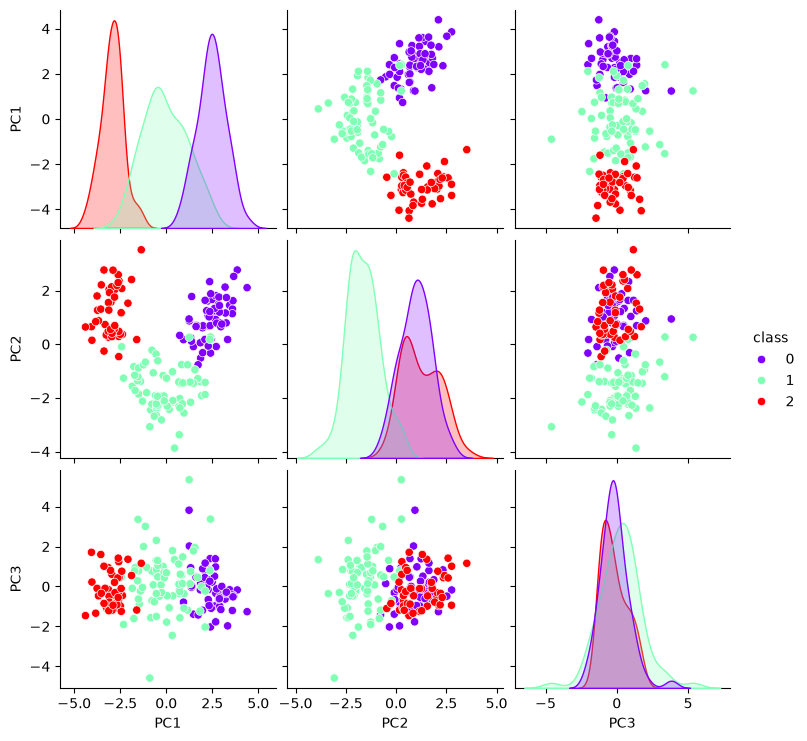

In [50]:
sbn.pairplot(df_pca, hue="class", palette="rainbow")

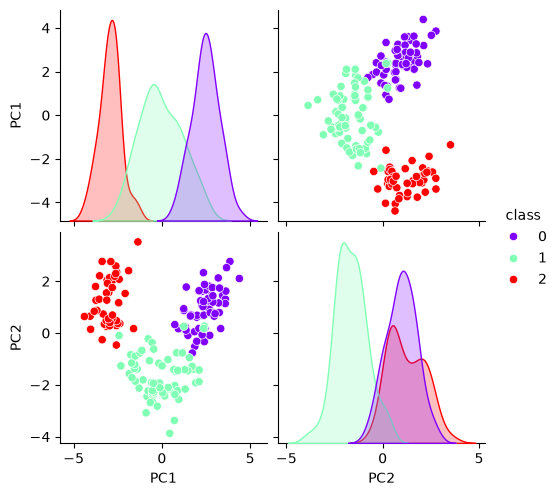

In [51]:
sbn.pairplot(df_pca_2, hue="class", palette="rainbow")